In [3]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: c:\Users\Daniel\ewallet-sentiment-analysis\venv\Scripts\python.exe
Python version: 3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]


In [4]:
%pip install pandas matplotlib seaborn tqdm langdetect emoji google-play-scraper

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
print("✅ Libraries loaded")
print(f"Pandas version: {pd.__version__}")

df = pd.read_csv("reviews_raw_combined_20260605.csv")
print(f"✅ Loaded {len(df):,} reviews")
df.head(3)

✅ Libraries loaded
Pandas version: 3.0.3
✅ Loaded 248,858 reviews


,app_name,scraped_lang,userName,score,content,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,Touch n Go eWallet,en,A Google user,5,apps yg sngt berguna,0,1.9.0,2026-06-04 16:02:02,NaN,NaN
1,Touch n Go eWallet,en,A Google user,5,good,0,1.9.0,2026-06-04 15:53:41,NaN,NaN
2,Touch n Go eWallet,en,A Google user,5,nice app,0,1.8.98,2026-06-04 12:59:24,NaN,NaN


In [ ]:
#Phase 2: Data Cleaning
#Full audit of dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 200)
sns.set_style("whitegrid")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)

Shape: (248858, 10)

Columns: ['app_name', 'scraped_lang', 'userName', 'score', 'content', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']

Missing values per column:
app_name                    0
scraped_lang                0
userName                    0
score                       0
content                    14
thumbsUpCount               0
reviewCreatedVersion    45155
at                          0
replyContent            79634
repliedAt               79634
dtype: int64

Data types:
app_name                  str
scraped_lang              str
userName                  str
score                   int64
content                   str
thumbsUpCount           int64
reviewCreatedVersion      str
at                        str
replyContent              str
repliedAt                 str
dtype: object


In [7]:
#read real samples
for app in df["app_name"].unique():
    print(f"\n{'='*60}")
    print(f"📱 {app}")
    print('='*60)
    sample = df[df["app_name"] == app].sample(3, random_state=42)
    for _, row in sample.iterrows():
        print(f"\n[⭐ {row['score']}] [{row['scraped_lang']}] {row['content'][:200]}")


📱 Touch n Go eWallet

[⭐ 1] [ms] Payah jugak aku dah tukar no pastu bila download balik app ni nak login takleh sebab acc aku connect dengan no lama aku. Sekarang nak create acc baru pun takleh

[⭐ 5] [en] mudah

[⭐ 1] [en] why after update i cannot topup my card using nfc anymore. ayyy please fix this

📱 MAE by Maybank

[⭐ 5] [ms] Ok

[⭐ 2] [en] Kenapa Mae ni asyik kena masuk password dua tiga kali padahal dah log in awal2

[⭐ 1] [en] Have to try three times to get the app to give me the secure2u verification, even after going into the secure2u section of the app. What a waste of time.

📱 Setel

[⭐ 4] [en] 👏🏻👏🏻💪💪🤲🤲🎉🎉

[⭐ 5] [en] memudahkn pengguna

[⭐ 5] [en] Terbaik

📱 Boost

[⭐ 3] [ms] Ok

[⭐ 3] [en] i suppose to get a 50% rebate but i still didn't get it...please fix it soon

[⭐ 5] [en] good job

📱 GXBank

[⭐ 1] [en] U can't even reinstall the apps and login.. so many issues, i don't even recounts how many times i need to take selfies just to try login.. the worst part is the sugg

In [8]:
# --- Data Cleaning ---
print(f"Before cleaning: {len(df):,}")

# 1. Drop rows with no review text
df = df.dropna(subset=["content"])
print(f"After dropping null content: {len(df):,}")

# 2. Strip whitespace
df["content"] = df["content"].astype(str).str.strip()

# 3. Remove duplicates (same user + same content)
df = df.drop_duplicates(subset=["userName", "content"], keep="first")
print(f"After removing duplicates: {len(df):,}")

# 4. Remove very short reviews (< 3 words)
df["word_count"] = df["content"].str.split().str.len()
df = df[df["word_count"] >= 3]
print(f"After removing <3 word reviews: {len(df):,}")

# 5. Parse review date
df["at"] = pd.to_datetime(df["at"], errors="coerce")
df["year"] = df["at"].dt.year
df["year_month"] = df["at"].dt.to_period("M").astype(str)

# 6. Reset index
df = df.reset_index(drop=True)

print(f"\nFinal cleaned shape: {df.shape}")
print(f"Date range: {df['at'].min()} → {df['at'].max()}")

Before cleaning: 248,858
After dropping null content: 248,844
After removing duplicates: 161,135
After removing <3 word reviews: 137,182

Final cleaned shape: (137182, 13)
Date range: 2016-12-15 14:21:26 → 2026-06-04 16:27:39


In [9]:
# Language detection on sample (test first)
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

def detect_lang_safe(text):
    try:
        return detect(text)
    except:
        return "unknown"

sample = df.sample(5000, random_state=42).copy()
sample["detected_lang"] = sample["content"].apply(detect_lang_safe)

print(sample["detected_lang"].value_counts().head(10))

detected_lang
en    2790
id    1751
tl      91
af      50
so      32
no      29
fr      28
da      21
sl      21
cy      20
Name: count, dtype: int64


In [ ]:
#Full language detection on entire dataset (with progress bar)
from tqdm import tqdm
tqdm.pandas()

df["detected_lang"] = df["content"].progress_apply(detect_lang_safe)

def simplify_lang(lang):
    if lang == "en":
        return "english"
    elif lang in ["ms", "id"]:
        return "malay"
    else:
        return "other"

df["lang_group"] = df["detected_lang"].apply(simplify_lang)
print(df["lang_group"].value_counts())

100%|██████████| 137182/137182 [2:56:51<00:00, 12.93it/s]    

lang_group
english    77744
malay      46789
other      12649
Name: count, dtype: int64


In [11]:
#Save cleaned dataset
df.to_csv("reviews_cleaned.csv", index=False)
print(f"✅ Saved {len(df):,} cleaned reviews")

✅ Saved 137,182 cleaned reviews


In [ ]:
#Phase 3: Sentiment Analysis
#Install Vader for sentiment analysis
%pip install vaderSentiment


   ---------------------------------------- 0/6 [urllib3]
   ---------------------------------------- 0/6 [urllib3]
   ------ --------------------------------- 1/6 [idna]
   ------------- -------------------------- 2/6 [charset_normalizer]
   -------------------------- ------------- 4/6 [requests]
   ---------------------------------------- 6/6 [vaderSentiment]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#Reload cleaned dataset for exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()

pd.set_option('display.max_colwidth', 200)
sns.set_style("whitegrid")

df = pd.read_csv("reviews_cleaned.csv")
print(f"Loaded {len(df):,} reviews")
print(df["lang_group"].value_counts())

Loaded 137,182 reviews
lang_group
english    77744
malay      46789
other      12649
Name: count, dtype: int64


In [2]:
#Run VADER on English reviews
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    try:
        scores = analyzer.polarity_scores(str(text))
        return scores["compound"]   # range: -1 (very neg) to +1 (very pos)
    except:
        return 0.0

# Apply only to English reviews (faster + more accurate)
english_mask = df["lang_group"] == "english"
print(f"Running VADER on {english_mask.sum():,} English reviews...")

df["vader_compound"] = np.nan
df.loc[english_mask, "vader_compound"] = (
    df.loc[english_mask, "content"].progress_apply(get_vader_sentiment)
)

print("✅ VADER done")
print(df.loc[english_mask, "vader_compound"].describe())

Running VADER on 77,744 English reviews...


100%|██████████| 77744/77744 [00:03<00:00, 21633.26it/s]

✅ VADER done
count    77744.000000
mean         0.125988
std          0.513185
min         -0.999800
25%         -0.275500
50%          0.077200
75%          0.571900
max          0.999700
Name: vader_compound, dtype: float64


In [3]:
#Convert scores to labels
def label_sentiment(score):
    if pd.isna(score):
        return np.nan
    elif score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["vader_label"] = df["vader_compound"].apply(label_sentiment)

print("Sentiment label distribution (English only):")
print(df[english_mask]["vader_label"].value_counts())

Sentiment label distribution (English only):
vader_label
positive    39276
negative    24188
neutral     14280
Name: count, dtype: int64


In [4]:
#Sanity check: does VADER agree with star ratings?
# Cross-tab: star rating vs VADER label
crosstab = pd.crosstab(
    df.loc[english_mask, "score"],
    df.loc[english_mask, "vader_label"],
    normalize="index"
) * 100

print("Star rating vs VADER label (% within each rating):")
print(crosstab.round(1))

Star rating vs VADER label (% within each rating):
vader_label  negative  neutral  positive
score                                   
1                51.2     21.4      27.4
2                39.5     24.3      36.3
3                29.5     23.1      47.4
4                14.8     16.6      68.6
5                 4.3     11.7      84.0


In [5]:
## Average sentiment score per app (English only)
avg_sentiment = (
    df[english_mask]
    .groupby("app_name")["vader_compound"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)
print(avg_sentiment.round(3))

                     mean  median  count
app_name                                
Setel               0.363   0.440   8829
Boost               0.211   0.296  19900
GXBank              0.090   0.000   1843
Touch n Go eWallet  0.088   0.000  32318
MAE by Maybank     -0.041   0.000  14854


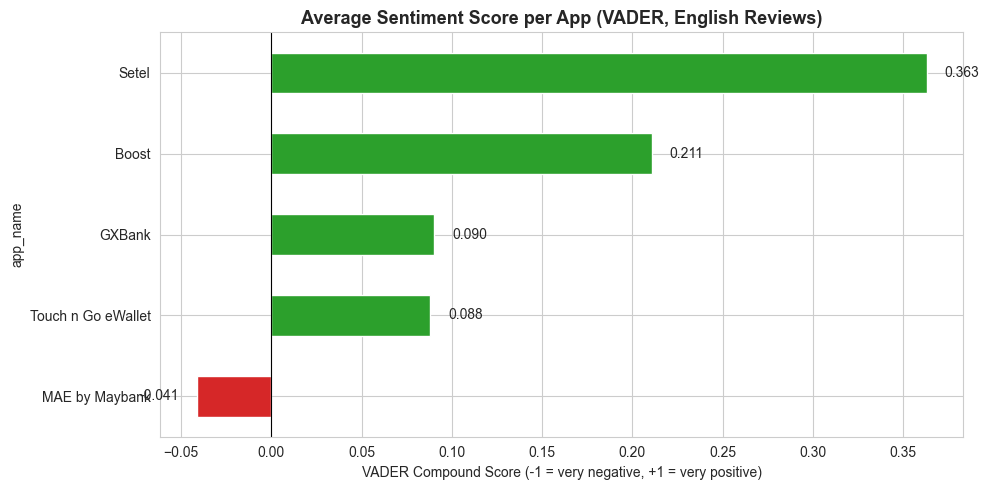

In [6]:
#Visualize sentiment distribution for English reviews
fig, ax = plt.subplots(figsize=(10, 5))
mean_scores = (
    df[english_mask]
    .groupby("app_name")["vader_compound"]
    .mean()
    .sort_values()
)
colors = ["#d62728" if v < 0 else "#2ca02c" for v in mean_scores]
mean_scores.plot(kind="barh", color=colors, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Average Sentiment Score per App (VADER, English Reviews)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("VADER Compound Score (-1 = very negative, +1 = very positive)")
for i, v in enumerate(mean_scores):
    ax.text(v + 0.01 if v >= 0 else v - 0.01, i, f"{v:.3f}",
            va="center", ha="left" if v >= 0 else "right")
plt.tight_layout()
plt.savefig("phase3_vader_by_app.png", dpi=150, bbox_inches="tight")
plt.show()

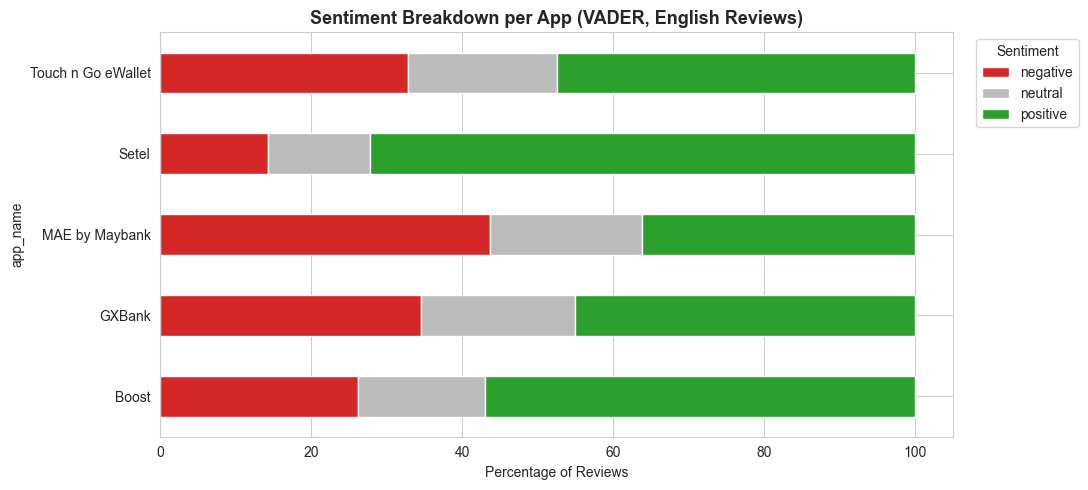

In [7]:
# Stacked bar: % positive / neutral / negative per app
fig, ax = plt.subplots(figsize=(11, 5))
label_dist = (
    df[english_mask]
    .groupby(["app_name", "vader_label"])
    .size()
    .unstack(fill_value=0)
)
label_dist_pct = label_dist.div(label_dist.sum(axis=1), axis=0) * 100
label_dist_pct = label_dist_pct[["negative", "neutral", "positive"]]
label_dist_pct.plot(kind="barh", stacked=True,
                    color=["#d62728", "#bbbbbb", "#2ca02c"], ax=ax)
ax.set_title("Sentiment Breakdown per App (VADER, English Reviews)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Percentage of Reviews")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig("phase3_vader_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
df.to_csv("reviews_with_vader.csv", index=False)
print(f"✅ Saved {len(df):,} reviews with VADER scores")

✅ Saved 137,182 reviews with VADER scores


In [10]:
import pandas as pd

# Load both files
vader_df = pd.read_csv("reviews_with_vader.csv")
transformer_df = pd.read_csv("reviews_with_transformer.csv")

# Merge transformer columns into the VADER-enriched dataframe
# We match on content + userName since indices may differ
transformer_cols = ["transformer_label", "transformer_score",
                    "prob_negative", "prob_neutral", "prob_positive"]

# Align by index (both dataframes were saved from the same cleaned base)
df = vader_df.copy()
for col in transformer_cols:
    df[col] = transformer_df[col].values

print(f"Master dataframe: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Save the final master dataset
df.to_csv("reviews_master.csv", index=False)
print("✅ Saved reviews_master.csv")

Master dataframe: (137182, 22)
Columns: ['app_name', 'scraped_lang', 'userName', 'score', 'content', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'word_count', 'year', 'year_month', 'detected_lang', 'lang_group', 'vader_compound', 'vader_label', 'transformer_label', 'transformer_score', 'prob_negative', 'prob_neutral', 'prob_positive']
✅ Saved reviews_master.csv


In [11]:
both_mask = df["lang_group"] == "english"
comparison = df[both_mask].copy()

agreement = (comparison["vader_label"] == comparison["transformer_label"]).mean() * 100
print(f"Overall agreement between VADER and Transformer: {agreement:.1f}%")

one_star = comparison[comparison["score"] == 1]
print(f"\n1-star reviews labeled 'negative':")
print(f"  VADER:       {(one_star['vader_label'] == 'negative').mean() * 100:.1f}%")
print(f"  Transformer: {(one_star['transformer_label'] == 'negative').mean() * 100:.1f}%")

five_star = comparison[comparison["score"] == 5]
print(f"\n5-star reviews labeled 'positive':")
print(f"  VADER:       {(five_star['vader_label'] == 'positive').mean() * 100:.1f}%")
print(f"  Transformer: {(five_star['transformer_label'] == 'positive').mean() * 100:.1f}%")

Overall agreement between VADER and Transformer: 59.1%

1-star reviews labeled 'negative':
  VADER:       51.2%
  Transformer: 92.8%

5-star reviews labeled 'positive':
  VADER:       84.0%
  Transformer: 74.3%


In [12]:
#Phase 5
#Define bilingual aspects
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Reload master if needed (skip if df is still in memory)
df = pd.read_csv("reviews_master.csv")
print(f"Loaded {len(df):,} reviews")

# Multilingual aspect dictionary
ASPECTS = {
    "Login/Authentication": [
        "login", "log in", "log-in", "sign in", "signin", "password", "pin",
        "secure2u", "biometric", "fingerprint", "face id", "otp", "verification",
        "masuk", "kata laluan", "pengesahan", "tak boleh login", "cannot login"
    ],
    "Reload/Top-up": [
        "reload", "topup", "top up", "top-up", "recharge", "balance", "saldo",
        "isi", "tambah baki", "tambah duit", "minimum reload"
    ],
    "Transaction/Payment": [
        "transfer", "duitnow", "duit now", "qr", "scan", "pay", "payment",
        "transaction", "bayar", "pembayaran", "hantar duit", "send money",
        "failed transaction", "pending", "tertangguh"
    ],
    "Customer Service": [
        "customer service", "careline", "support", "helpline", "helpdesk",
        "complaint", "agent", "live chat", "respond", "reply", "khidmat pelanggan",
        "tak membantu", "no response", "tiada balasan"
    ],
    "App Performance/UI": [
        "lag", "slow", "lambat", "lemot", "hang", "crash", "freeze", "stuck",
        "loading", "buffer", "buggy", "glitch", "error", "ralat", "force close",
        "tak boleh buka", "cannot open", "interface", "ui", "design"
    ],
    "Rewards/Cashback": [
        "cashback", "reward", "rewards", "points", "boost stars", "grabreward",
        "grabunlimited", "voucher", "promo", "promotion", "ganjaran", "mata"
    ],
    "Update/Version": [
        "update", "version", "upgrade", "new version", "after update",
        "since update", "kemaskini", "versi baru"
    ],
    "Security/Fraud": [
        "secure", "security", "hack", "hacked", "fraud", "phishing", "scam",
        "kena tipu", "penipu", "selamat", "keselamatan", "unauthorized"
    ],
    "Account/Registration": [
        "account", "akaun", "register", "registration", "sign up", "signup",
        "ekyc", "kyc", "verify", "mykad", "ic", "verification process", "daftar"
    ],
}

print(f"Defined {len(ASPECTS)} aspect categories")
print(f"Total keywords: {sum(len(v) for v in ASPECTS.values())}")

Loaded 137,182 reviews
Defined 9 aspect categories
Total keywords: 123


In [13]:
#Tag each review with the aspects it mentions
def find_aspects(text):
    """Return list of aspects mentioned in the text."""
    if pd.isna(text):
        return []
    text_lower = str(text).lower()
    found = []
    for aspect, keywords in ASPECTS.items():
        for kw in keywords:
            if " " in kw:
                if kw in text_lower:
                    found.append(aspect)
                    break
            else:
                if re.search(rf"\b{re.escape(kw)}\b", text_lower):
                    found.append(aspect)
                    break
    return found

from tqdm import tqdm
tqdm.pandas()

df["aspects"] = df["content"].progress_apply(find_aspects)
df["num_aspects"] = df["aspects"].apply(len)

print("\nAspect mention frequency:")
all_aspects = [a for lst in df["aspects"] for a in lst]
aspect_counts = pd.Series(all_aspects).value_counts()
print(aspect_counts)

print(f"\nReviews mentioning ≥1 aspect: {(df['num_aspects'] > 0).sum():,} ({(df['num_aspects'] > 0).mean()*100:.1f}%)")
print(f"Reviews mentioning 0 aspects (generic): {(df['num_aspects'] == 0).sum():,}")

100%|██████████| 137182/137182 [00:18<00:00, 7335.94it/s]


Aspect mention frequency:
Transaction/Payment     19234
Login/Authentication    17220
Account/Registration    15020
Reload/Top-up           14390
Update/Version          12186
App Performance/UI      10184
Customer Service         5002
Rewards/Cashback         4854
Security/Fraud           3343
Name: count, dtype: int64

Reviews mentioning ≥1 aspect: 70,459 (51.4%)
Reviews mentioning 0 aspects (generic): 66,723


In [14]:
#The killer table: sentiment per app per aspect
exploded = df[df["num_aspects"] > 0].explode("aspects")

aspect_sentiment = (
    exploded.groupby(["app_name", "aspects"])["transformer_score"]
    .agg(["mean", "count"])
    .reset_index()
)

sentiment_pivot = aspect_sentiment.pivot(
    index="app_name", columns="aspects", values="mean"
)
count_pivot = aspect_sentiment.pivot(
    index="app_name", columns="aspects", values="count"
)

print("=== AVERAGE SENTIMENT BY APP × ASPECT ===")
print(sentiment_pivot.round(2))

print("\n=== REVIEW COUNT BY APP × ASPECT ===")
print(count_pivot.fillna(0).astype(int))

=== AVERAGE SENTIMENT BY APP × ASPECT ===
aspects             Account/Registration  App Performance/UI  \
app_name                                                       
Boost                              -0.59               -0.69   
GXBank                             -0.54               -0.47   
MAE by Maybank                     -0.66               -0.68   
Setel                              -0.38               -0.47   
Touch n Go eWallet                 -0.62               -0.69   

aspects             Customer Service  Login/Authentication  Reload/Top-up  \
app_name                                                                    
Boost                          -0.65                 -0.64          -0.36   
GXBank                         -0.58                 -0.71          -0.43   
MAE by Maybank                 -0.70                 -0.71          -0.53   
Setel                          -0.24                 -0.55          -0.16   
Touch n Go eWallet             -0.67           

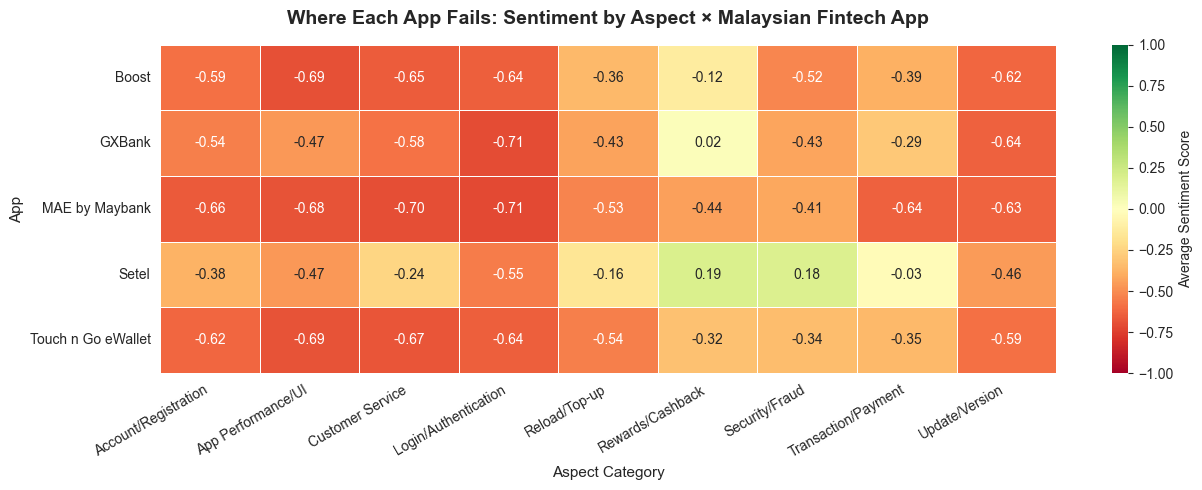

In [15]:
#The heatmap: average sentiment per aspect per app
fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    sentiment_pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    cbar_kws={"label": "Average Sentiment Score"},
    linewidths=0.5,
    ax=ax
)
ax.set_title(
    "Where Each App Fails: Sentiment by Aspect × Malaysian Fintech App",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Aspect Category", fontsize=11)
ax.set_ylabel("App", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("phase5_aspect_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
#Automated insights generation
print("=== WHERE EACH APP IS WORST ===\n")
for aspect in sentiment_pivot.columns:
    worst_app = sentiment_pivot[aspect].idxmin()
    worst_score = sentiment_pivot[aspect].min()
    print(f"{aspect:25s} → worst: {worst_app:20s} ({worst_score:+.2f})")

print("\n=== EACH APP'S BIGGEST WEAKNESS ===\n")
for app in sentiment_pivot.index:
    weakest = sentiment_pivot.loc[app].idxmin()
    score = sentiment_pivot.loc[app].min()
    print(f"{app:22s} → weakest at: {weakest:25s} ({score:+.2f})")

print("\n=== EACH APP'S BIGGEST STRENGTH ===\n")
for app in sentiment_pivot.index:
    strongest = sentiment_pivot.loc[app].idxmax()
    score = sentiment_pivot.loc[app].max()
    print(f"{app:22s} → strongest at: {strongest:25s} ({score:+.2f})")

=== WHERE EACH APP IS WORST ===

Account/Registration      → worst: MAE by Maybank       (-0.66)
App Performance/UI        → worst: Boost                (-0.69)
Customer Service          → worst: MAE by Maybank       (-0.70)
Login/Authentication      → worst: MAE by Maybank       (-0.71)
Reload/Top-up             → worst: Touch n Go eWallet   (-0.54)
Rewards/Cashback          → worst: MAE by Maybank       (-0.44)
Security/Fraud            → worst: Boost                (-0.52)
Transaction/Payment       → worst: MAE by Maybank       (-0.64)
Update/Version            → worst: GXBank               (-0.64)

=== EACH APP'S BIGGEST WEAKNESS ===

Boost                  → weakest at: App Performance/UI        (-0.69)
GXBank                 → weakest at: Login/Authentication      (-0.71)
MAE by Maybank         → weakest at: Login/Authentication      (-0.71)
Setel                  → weakest at: Login/Authentication      (-0.55)
Touch n Go eWallet     → weakest at: App Performance/UI        (-0.69

In [17]:
#Save the aspect-level sentiment data for further analysis
df.to_csv("reviews_master_with_aspects.csv", index=False)
sentiment_pivot.to_csv("aspect_sentiment_pivot.csv")
count_pivot.to_csv("aspect_count_pivot.csv")
print("✅ Saved aspect-tagged master + pivots")

✅ Saved aspect-tagged master + pivots


In [18]:
def show_examples(app, aspect, n=5, sentiment="negative"):
    """Show representative reviews for an app × aspect combo."""
    sub = df[
        (df["app_name"] == app)
        & (df["aspects"].apply(lambda lst: aspect in lst))
        & (df["transformer_label"] == sentiment)
    ].copy()
    
    # Sort by extremity (most negative first) and review length
    if sentiment == "negative":
        sub = sub.sort_values("transformer_score", ascending=True)
    else:
        sub = sub.sort_values("transformer_score", ascending=False)
    
    print(f"\n{'='*70}")
    print(f"📱 {app} → {aspect} ({sentiment.upper()})")
    print(f"{'='*70}")
    
    for _, row in sub.head(n).iterrows():
        date = str(row["at"])[:10]
        print(f"\n[⭐{row['score']}] [{date}] [{row['lang_group']}] (score={row['transformer_score']:+.2f})")
        print(f"  {row['content'][:300]}")

In [19]:
# DRILL 1: MAE's login crisis
show_examples("MAE by Maybank", "Login/Authentication", n=8)


📱 MAE by Maybank → Login/Authentication (NEGATIVE)

[⭐2] [2022-03-23] [english] (score=-0.95)
  to be honest I am so upset with your so call new apps...the BEST IS STILL THE VERY OLD CLASSIC APP. SIMPLY CANNOT USE THE SECURE2U..

[⭐2] [2024-01-31] [english] (score=-0.95)
  I cannot transfer due to secure2u, ask me to go to nearby ATM? Wtheck is that, you supposedly help us, not making us hard. This apps are truly annoying

[⭐1] [2023-02-04] [english] (score=-0.95)
  Just terrible and not user friendly at all. Login in feels just so frustrating, as the app refused to accept the correct password. I just have bad experience with this app!

[⭐1] [2024-10-27] [english] (score=-0.95)
  rubbish ui, horrible experience, locked me out for 24hr for reseting password

[⭐1] [2023-08-05] [english] (score=-0.95)
  Worst app ever. Please stop requesting us to reset your password frequently. It's 2 times for me already. Not only that, I can't use my previously used password and I had to wait 24 hours

In [20]:
# DRILL 2: TNG's reload problem
show_examples("Touch n Go eWallet", "Reload/Top-up", n=8)


📱 Touch n Go eWallet → Reload/Top-up (NEGATIVE)

[⭐1] [2023-07-28] [english] (score=-0.96)
  Sry but this app has too much going on and too confusing to use. Why force the user to use duitnow to top up the ewallet, where is your online banking option?? How do you expect the less tech savvy people to use this app? I have no idea what's the agenda but I feel disgusted. Very disappointed.

[⭐1] [2023-08-22] [english] (score=-0.96)
  It's the worst app. Too many pop ups which disrupt the user experience. All you want to do is top up. This touch no go app is an absolutely nightmare. It states anymore than RM10 will go to Go+. I don't want to use this damn Go+. It's the stupidest policy and creates the worst experience. Brains beh

[⭐1] [2018-10-04] [english] (score=-0.95)
  I just got trap with this useless apps. Doesn't meet the purpose of helping users to reload online. Now my rm50 got stuck in the ewallet. So dissappointing 😡

[⭐1] [2018-10-23] [english] (score=-0.95)
  Why can't I relo

In [21]:
# DRILL 3: What does Setel do RIGHT?
show_examples("Setel", "Rewards/Cashback", n=8, sentiment="positive")


📱 Setel → Rewards/Cashback (POSITIVE)

[⭐5] [2023-06-03] [english] (score=+0.92)
  Great reward items to offer, keep it like this always!

[⭐5] [2022-06-12] [english] (score=+0.91)
  Very convenient, good experience, good rewards, keep it up

[⭐5] [2024-10-10] [english] (score=+0.91)
  Easy to use and the rewards are awesome!

[⭐5] [2022-02-28] [english] (score=+0.90)
  Very interesting apps with rewards for you, easier and practical. I love it very much

[⭐5] [2025-08-17] [english] (score=+0.90)
  Setel is hands down the best app for earning points at petrol stations! Super easy to use, redeeming rewards is a breeze, and I’m honestly amazed by how convenient it is—I’m loving every bit of it!

[⭐5] [2021-02-26] [english] (score=+0.90)
  The app is very user-friendly and easier to refuel your car. Great UX and beautiful UI. There's more to redeem now with Mesra Points. Definitely recommend to those who use Petronas as their go-to petrol station.

[⭐5] [2020-03-28] [english] (score=+0.8

In [22]:
df.to_csv("reviews_master_with_aspects.csv", index=False)
sentiment_pivot.to_csv("aspect_sentiment_pivot.csv")

In [1]:
#Phase 6
#Install BERTopic for topic modeling
%pip install bertopic sentence-transformers

  Using cached bertopic-0.17.4-py3-none-any.whl.metadata (24 kB)
  Using cached sentence_transformers-5.5.1-py3-none-any.whl.metadata (18 kB)
Using cached bertopic-0.17.4-py3-none-any.whl (154 kB)
Using cached sentence_transformers-5.5.1-py3-none-any.whl (588 kB)

   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#Reload master dataset with aspects
import pandas as pd
import ast

df = pd.read_csv("reviews_master_with_aspects.csv")

# aspects column was saved as string — convert back to list
df["aspects"] = df["aspects"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

print(f"Loaded {len(df):,} reviews")

Loaded 137,182 reviews


In [6]:
#Focus on negative reviews (where insights live)
neg_df = df[df["transformer_label"] == "negative"].copy()
print(f"Total negative reviews: {len(neg_df):,}")

# Sample 20k for speed — patterns will still hold
neg_sample = neg_df.sample(20000, random_state=42).copy()
print(f"Modeling on {len(neg_sample):,} negative reviews")

Total negative reviews: 76,330
Modeling on 20,000 negative reviews


In [7]:
#Run BERTopic to find common themes in negative reviews
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Multilingual embedding model — handles English + Malay
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=100,
    nr_topics=15,
    verbose=True
)

texts = neg_sample["content"].astype(str).tolist()
topics, probs = topic_model.fit_transform(texts)

print("✅ Topic modeling complete")

c:\Users\Daniel\ewallet-sentiment-analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13681.71it/s]
2026-06-06 02:15:13,726 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 625/625 [01:18<00:00,  7.97it/s]
2026-06-06 02:16:32,350 - BERTopic - Embedding - Completed ✓
2026-06-06 02:16:32,351 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-06 02:16:47,177 - BERTopic - Dimensionality - Completed ✓
2026-06-06 02:16:47,178 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-06 02:16:49,254 - BERTopic - Cluster - Completed ✓
2026-06-06 02:16:49,254 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-06 02:16:49,437 - BERTo

✅ Topic modeling complete


In [8]:
#See what emerged
topic_info = topic_model.get_topic_info()
print(topic_info)

    Topic  Count                                  Name  \
0      -1   7121                     -1_to_the_and_app   
1       0   3506                     0_app_the_to_apps   
2       1   2296                     1_tak_nk_ni_boleh   
3       2   2214              2_password_number_my_log   
4       3   1182                3_duit_money_wallet_my   
5       4    960            4_update_download_nak_kena   
6       5    597                     5_boost_to_the_my   
7       6    570         6_face_verify_verification_to   
8       7    351               7_slow_app_loading_very   
9       8    345          8_service_customer_server_to   
10      9    243  9_notification_notifications_ads_the   
11     10    216                   10_qr_code_scan_pay   
12     11    169                   11_rm5_rm50_rm10_rm   
13     12    124       12_petrol_pump_station_petronas   
14     13    106      13_receipt_share_transaction_the   

                                       Representation  \
0     [to, the

In [9]:
#Topic per app
neg_sample["topic"] = topics

print("\n=== TOP COMPLAINT TOPICS PER APP ===\n")
for app in neg_sample["app_name"].unique():
    sub = neg_sample[neg_sample["app_name"] == app]
    top_topics = sub["topic"].value_counts().head(5)
    print(f"\n📱 {app}")
    print("-" * 50)
    for topic_id, count in top_topics.items():
        if topic_id == -1:
            continue
        words = topic_model.get_topic(topic_id)[:6]
        word_str = ", ".join([w[0] for w in words])
        print(f"  Topic {topic_id} ({count:,} reviews): {word_str}")

print("\n=== TOP COMPLAINT TOPICS PER APP ===\n")
for app in neg_sample["app_name"].unique():
    sub = neg_sample[neg_sample["app_name"] == app]
    top_topics = sub["topic"].value_counts().head(5)
    print(f"\n📱 {app}")
    print("-" * 50)
    for topic_id, count in top_topics.items():
        if topic_id == -1:
            continue
        words = topic_model.get_topic(topic_id)[:6]
        word_str = ", ".join([w[0] for w in words])
        print(f"  Topic {topic_id} ({count:,} reviews): {word_str}")


=== TOP COMPLAINT TOPICS PER APP ===


📱 Boost
--------------------------------------------------
  Topic 0 (541 reviews): app, the, to, apps, this, card
  Topic 5 (532 reviews): boost, to, the, my, and, is
  Topic 1 (524 reviews): tak, nk, ni, boleh, nak, kenapa
  Topic 2 (432 reviews): password, number, my, log, account, in

📱 MAE by Maybank
--------------------------------------------------
  Topic 0 (1,104 reviews): app, the, to, apps, this, card
  Topic 2 (525 reviews): password, number, my, log, account, in
  Topic 1 (515 reviews): tak, nk, ni, boleh, nak, kenapa
  Topic 4 (447 reviews): update, download, nak, kena, to, tak

📱 Touch n Go eWallet
--------------------------------------------------
  Topic 0 (1,604 reviews): app, the, to, apps, this, card
  Topic 2 (1,142 reviews): password, number, my, log, account, in
  Topic 1 (1,128 reviews): tak, nk, ni, boleh, nak, kenapa
  Topic 3 (683 reviews): duit, money, wallet, my, transfer, tak

📱 Setel
--------------------------------

In [10]:
#Save output for further analysis
# Save HTML visualizations
fig_bars = topic_model.visualize_barchart(top_n_topics=10, n_words=8)
fig_bars.write_html("phase6_topics_barchart.html")

fig_map = topic_model.visualize_topics()
fig_map.write_html("phase6_topics_map.html")

# Save the model + topic assignments
topic_model.save("phase6_bertopic_model", serialization="safetensors")
neg_sample[["app_name", "content", "transformer_score", "topic"]].to_csv(
    "phase6_topic_assignments.csv", index=False
)
print("✅ Saved topic model + visualizations + assignments")

✅ Saved topic model + visualizations + assignments


In [ ]:
#Re-run BERTopic with bilingual stopword filtering
%pip install scikit-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from sklearn.feature_extraction.text import CountVectorizer

# English + Malay stopwords combined
malay_stopwords = [
    "yang", "untuk", "pada", "dengan", "dari", "akan", "ini", "itu", "saya",
    "kita", "kami", "anda", "boleh", "tidak", "tak", "ada", "atau", "jadi",
    "kalau", "lagi", "juga", "saja", "pun", "dah", "nak", "ni", "tu", "ya",
    "la", "lah", "kan", "ke", "di", "yg", "tp", "tpi", "tapi", "macam", "mcm",
    "bila", "bagi", "ke", "dlm", "dgn", "sbb", "sebab", "kenapa", "mana",
    "bagaimana", "bagai", "macamana", "buat", "guna", "guna", "buat", "kena",
    "nk", "x", "xde", "xleh", "xboleh", "tk", "ble", "klu", "klau", "btw"
]

english_stopwords = [
    "the", "and", "is", "in", "to", "of", "a", "this", "that", "for", "on",
    "with", "as", "are", "was", "but", "i", "my", "me", "you", "your", "we",
    "us", "our", "be", "been", "have", "has", "had", "do", "does", "did",
    "will", "would", "could", "should", "may", "can", "cant", "wont", "dont",
    "im", "its", "very", "really", "just", "so", "too", "also", "even",
    "still", "yet", "now", "then", "when", "where", "why", "how", "what",
    "which", "who", "all", "any", "some", "no", "not", "only", "or", "if",
    "than", "from", "by", "at", "an", "it", "they", "them", "their", "there",
    "here", "up", "down", "out", "over", "under", "again", "more", "most",
    "much", "many", "few", "lot", "lots", "use", "using", "used", "get",
    "got", "give", "make", "made", "go", "going", "want", "need", "like"
]

stop_words = list(set(english_stopwords + malay_stopwords))

# Create custom vectorizer that excludes stopwords
vectorizer_model = CountVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),  # also captures phrases like "tak boleh", "cannot login"
    min_df=10
)

In [14]:
## Rebuild the topic model with proper stopword filtering
topic_model_clean = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    min_topic_size=100,
    nr_topics=15,
    verbose=True
)

topics_clean, _ = topic_model_clean.fit_transform(texts)
print("✅ Clean topic model done")

2026-06-06 02:23:08,200 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 625/625 [01:16<00:00,  8.13it/s]
2026-06-06 02:24:25,167 - BERTopic - Embedding - Completed ✓
2026-06-06 02:24:25,168 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-06 02:24:27,007 - BERTopic - Dimensionality - Completed ✓
2026-06-06 02:24:27,008 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-06 02:24:29,107 - BERTopic - Cluster - Completed ✓
2026-06-06 02:24:29,107 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-06 02:24:29,420 - BERTopic - Representation - Completed ✓
2026-06-06 02:24:29,421 - BERTopic - Topic reduction - Reducing number of topics
2026-06-06 02:24:29,430 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-06 02:24:29,733 - BERTopic - Representation - Completed ✓
2026-06-06 02:24:29,735 - BERTopic - Topic reduction - Re

✅ Clean topic model done


In [15]:
# View the cleaned topic info
topic_info_clean = topic_model_clean.get_topic_info()
print(topic_info_clean[["Topic", "Count", "Name"]].to_string())

    Topic  Count                                      Name
0      -1   6769                  -1_app_apps_mae_transfer
1       0   3624                    0_app_apps_card_update
2       1   2419                       1_masuk_dh_aku_buka
3       2   2345             2_password_number_account_log
4       3   1417              3_duit_money_wallet_transfer
5       4    969     4_update_download_menyusahkan_install
6       5    622                5_boost_rewards_reward_app
7       6    378                 6_slow_loading_app_lambat
8       7    334                         7_face_ic_scan_id
9       8    254  8_service_customer_customer service_call
10      9    242           9_notification_off_pop_annoying
11     10    213                   10_qr_qr code_code_scan
12     11    162                    11_rm50_rm_dapat_claim
13     12    130            12_petrol_station_setel_detect
14     13    122                 13_number_app_ewallet_tng


In [ ]:
#Topic per app with cleaned model
neg_sample["topic_clean"] = topics_clean

print("\n=== TOP COMPLAINT TOPICS PER APP (CLEANED) ===\n")
for app in neg_sample["app_name"].unique():
    sub = neg_sample[neg_sample["app_name"] == app]
    top_topics = sub["topic_clean"].value_counts().head(5)
    print(f"\n📱 {app}")
    print("-" * 60)
    for topic_id, count in top_topics.items():
        if topic_id == -1:
            continue
        words = topic_model_clean.get_topic(topic_id)[:6]
        word_str = ", ".join([w[0] for w in words])
        print(f"  Topic {topic_id} ({count:,} reviews): {word_str}")


=== TOP COMPLAINT TOPICS PER APP (CLEANED) ===


📱 Boost
------------------------------------------------------------
  Topic 0 (559 reviews): app, apps, card, update, open, touch
  Topic 1 (557 reviews): masuk, dh, aku, buka, susah, daftar
  Topic 5 (555 reviews): boost, rewards, reward, app, after, please
  Topic 2 (443 reviews): password, number, account, log, reset, login

📱 MAE by Maybank
------------------------------------------------------------
  Topic 0 (1,193 reviews): app, apps, card, update, open, touch
  Topic 2 (536 reviews): password, number, account, log, reset, login
  Topic 1 (530 reviews): masuk, dh, aku, buka, susah, daftar
  Topic 4 (449 reviews): update, download, menyusahkan, install, kali, je

📱 Touch n Go eWallet
------------------------------------------------------------
  Topic 0 (1,599 reviews): app, apps, card, update, open, touch
  Topic 2 (1,250 reviews): password, number, account, log, reset, login
  Topic 1 (1,196 reviews): masuk, dh, aku, buka, susa

In [17]:
#Save clean model outputs
fig_bars_clean = topic_model_clean.visualize_barchart(top_n_topics=10, n_words=8)
fig_bars_clean.write_html("phase6_topics_barchart_clean.html")

topic_model_clean.save("phase6_bertopic_model_clean", serialization="safetensors")
neg_sample[["app_name", "content", "transformer_score", "topic_clean"]].to_csv(
    "phase6_topic_assignments_clean.csv", index=False
)
print("✅ Saved cleaned model")

✅ Saved cleaned model


In [18]:
# Save assignments + visualizations
neg_sample[["app_name", "content", "transformer_score", "topic_clean"]].to_csv(
    "phase6_topic_assignments_clean.csv", index=False
)

# Topic info table for the report
topic_info_clean[["Topic", "Count", "Name"]].to_csv(
    "phase6_topic_info.csv", index=False
)
print("✅ Saved Phase 6 outputs")

✅ Saved Phase 6 outputs


In [2]:
#Phase 7: Thematic Analysis & Storytelling
import pandas as pd
import os

df = pd.read_csv("reviews_master_with_aspects.csv")

cols_to_keep = [
    "app_name", "score", "content", "at",
    "lang_group", "transformer_label", "transformer_score"
]
slim = df[cols_to_keep].copy()

# Sample 6000 per app using an explicit loop (more reliable than groupby.apply)
sampled_parts = []
for app in slim["app_name"].unique():
    group = slim[slim["app_name"] == app]
    sample_size = min(len(group), 6000)
    sampled_parts.append(group.sample(sample_size, random_state=42))

slim = pd.concat(sampled_parts, ignore_index=True)

slim.to_csv("dashboard_data.csv", index=False)

# Verify
size_mb = os.path.getsize("dashboard_data.csv") / 1024 / 1024
print(f"✅ Saved {len(slim):,} reviews → dashboard_data.csv ({size_mb:.1f} MB)")
print(f"\nColumns: {slim.columns.tolist()}")
print("\nReview counts per app:")
print(slim["app_name"].value_counts())

✅ Saved 26,544 reviews → dashboard_data.csv (4.2 MB)

Columns: ['app_name', 'score', 'content', 'at', 'lang_group', 'transformer_label', 'transformer_score']

Review counts per app:
app_name
Touch n Go eWallet    6000
MAE by Maybank        6000
Setel                 6000
Boost                 6000
GXBank                2544
Name: count, dtype: int64


In [3]:
test = pd.read_csv("dashboard_data.csv")
print(test.columns.tolist())
print(test.head(3))

['app_name', 'score', 'content', 'at', 'lang_group', 'transformer_label', 'transformer_score']
             app_name  score  \
0  Touch n Go eWallet      2   
1  Touch n Go eWallet      2   
2  Touch n Go eWallet      1   

                                             content                   at  \
0  Recently there is changes where 1% is charging...  2023-11-22 22:24:19   
1  How come I don't have "my rewards" category on...  2020-02-08 16:11:11   
2  Why verification time is too long? Already 1mo...  2024-07-23 08:58:30   

  lang_group transformer_label  transformer_score  
0    english           neutral          -0.249806  
1    english          negative          -0.639764  
2    english          negative          -0.808428  
